# ML4_Classification problems

In [1]:
from collections import Counter

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import seaborn as sns

from category_encoders import CountEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [2]:
from my_utils import time_ordered_split_3

## 1. Download data

In [3]:
df = pd.read_csv("../datasets/train.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  object 
 3   Auction                            72983 non-null  object 
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  object 
 7   Model                              72983 non-null  object 
 8   Trim                               70623 non-null  object 
 9   SubModel                           72975 non-null  object 
 10  Color                              72975 non-null  object 
 11  Transmission                       72974 non-null  obj

In [5]:
df.head(5)

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


In [6]:
df.describe()

,RefId,IsBadBuy,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost
count,72983.000000,72983.000000,72983.000000,72983.000000,69814.000000,72983.000000,72965.000000,72965.000000,72965.000000,72965.000000,72668.000000,72668.000000,72668.000000,72668.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000
mean,36511.428497,0.122988,2005.343052,4.176644,1.494299,71499.995917,6128.909217,7373.636031,8497.034332,9850.928240,6132.081287,7390.681827,8775.723331,10145.385314,26345.842155,58043.059945,6730.934326,0.025280,1276.580985
std,21077.241302,0.328425,1.731252,1.712210,0.521290,14578.913128,2461.992768,2722.491986,3156.285284,3385.789541,2434.567723,2686.248852,3090.702941,3310.254351,25717.351219,26151.640415,1767.846435,0.156975,598.846788
min,1.000000,0.000000,2001.000000,0.000000,0.000000,4825.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,2764.000000,1.000000,0.000000,462.000000
25%,18257.500000,0.000000,2004.000000,3.000000,1.000000,61837.000000,4273.000000,5406.000000,6280.000000,7493.000000,4275.000000,5414.000000,6536.000000,7784.000000,17212.000000,32124.000000,5435.000000,0.000000,837.000000
50%,36514.000000,0.000000,2005.000000,4.000000,1.000000,73361.000000,6097.000000,7303.000000,8444.000000,9789.000000,6062.000000,7313.000000,8729.000000,10103.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000
75%,54764.500000,0.000000,2007.000000,5.000000,2.000000,82436.000000,7765.000000,9021.000000,10651.000000,12088.000000,7736.000000,9013.000000,10911.000000,12309.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000
max,73014.000000,1.000000,2010.000000,9.000000,3.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,45469.000000,1.000000,7498.000000


In [7]:
missing_data = df.isna().sum()
print(missing_data[missing_data > 0])

Trim                                  2360
SubModel                                 8
Color                                    8
Transmission                             9
WheelTypeID                           3169
WheelType                             3174
Nationality                              5
Size                                     5
TopThreeAmericanName                     5
MMRAcquisitionAuctionAveragePrice       18
MMRAcquisitionAuctionCleanPrice         18
MMRAcquisitionRetailAveragePrice        18
MMRAcquisitonRetailCleanPrice           18
MMRCurrentAuctionAveragePrice          315
MMRCurrentAuctionCleanPrice            315
MMRCurrentRetailAveragePrice           315
MMRCurrentRetailCleanPrice             315
PRIMEUNIT                            69564
AUCGUART                             69564
dtype: int64


In [8]:
df.groupby(df["PRIMEUNIT"].notna())["IsBadBuy"].mean()

PRIMEUNIT
False    0.12712
True     0.03890
Name: IsBadBuy, dtype: float64

In [9]:
df.groupby(df["AUCGUART"].notna())["IsBadBuy"].mean()

AUCGUART
False    0.12712
True     0.03890
Name: IsBadBuy, dtype: float64

In [10]:
df['AUCGUART'].notna().mean() == df['PRIMEUNIT'].notna().mean()

True

In [11]:
X = df.copy()
X["auction_has_info"] = X["AUCGUART"].notna().astype(int)
X = X.drop(columns=["PRIMEUNIT", "AUCGUART"])
X.shape

(72983, 33)

**AUCGUART**: The level guarntee provided by auction for the vehicle (Green light - Guaranteed/arbitratable, Yellow Light - caution/issue, red light - sold as is)

**PRIMEUNIT**: Identifies if the vehicle would have a higher demand than a standard purchase


The missing data rate in these two columns exceeds 95%. The features have identical missing data distributions; therefore, they likely represent the same factor. Proceeding with a single aggregated binary feature.

In [12]:
(1 - X[X.columns[X.isnull().mean() < 0.05]].notna().all(axis=1).mean()) * 100

7.8278503213077055

In [13]:
(1 - X[X.columns[X.isnull().mean() < 0.025]].notna().all(axis=1).mean()) * 100

0.4453091815902366

In [14]:
columns_drop = X.columns[(X.isnull().mean() < 0.025) & (X.isnull().mean() > 0)]
X = X.dropna(subset=columns_drop)
X.shape

(72658, 33)

Row-wise deletion is applied exclusively to features with a missing rate under 2.5%. Applying this to features with higher missingness would lead to an unacceptable loss of data (>5%)

In [15]:
missing_data_ = X.isna().sum()
missing_data_[missing_data_ > 0]

Trim           2357
WheelTypeID    3159
WheelType      3164
dtype: int64

In [16]:
df[["Trim", "WheelTypeID", "WheelType"]].head(10)

,Trim,WheelTypeID,WheelType
0,i,1.0,Alloy
1,ST,1.0,Alloy
2,SXT,2.0,Covers
3,SXT,1.0,Alloy
4,ZX3,2.0,Covers
5,ES,2.0,Covers
6,EX,2.0,Covers
7,SE,2.0,Covers
8,EX,2.0,Covers
9,SEL,1.0,Alloy


In [17]:
df.groupby(df["Trim"].notna())["IsBadBuy"].mean()

Trim
False    0.158475
True     0.121802
Name: IsBadBuy, dtype: float64

In [18]:
df.groupby(df["WheelTypeID"].notna())["IsBadBuy"].mean()

WheelTypeID
False    0.705585
True     0.096542
Name: IsBadBuy, dtype: float64

In [19]:
df.groupby(df["WheelType"].notna())["IsBadBuy"].mean()

WheelType
False    0.704789
True     0.096535
Name: IsBadBuy, dtype: float64

In [20]:
cols = ["WheelTypeID", "WheelType"]
df[df[cols].notna().sum(axis=1) == 1][cols]

,WheelTypeID,WheelType
2992,0.0,NaN
3926,0.0,NaN
42640,0.0,NaN
47731,0.0,NaN
69331,0.0,NaN


- WheelTypeID and WheelType are duplicate features.
- Missingness is identical — cannot impute from duplicate.
- Keeping WheelTypeID (1.0: Alloy, 2.0: Covers). NaN -> 0. 
- The mere presence of a missing value may itself serve as a signal flag in the future.
- Fill missing values in Trim column with "Unknown"

In [21]:
X = X.drop("WheelType", axis=1)
X["WheelTypeID"] = X["WheelTypeID"].fillna(0.0)
X["Trim"] = X["Trim"].fillna("Unknown")
X.shape

(72658, 32)

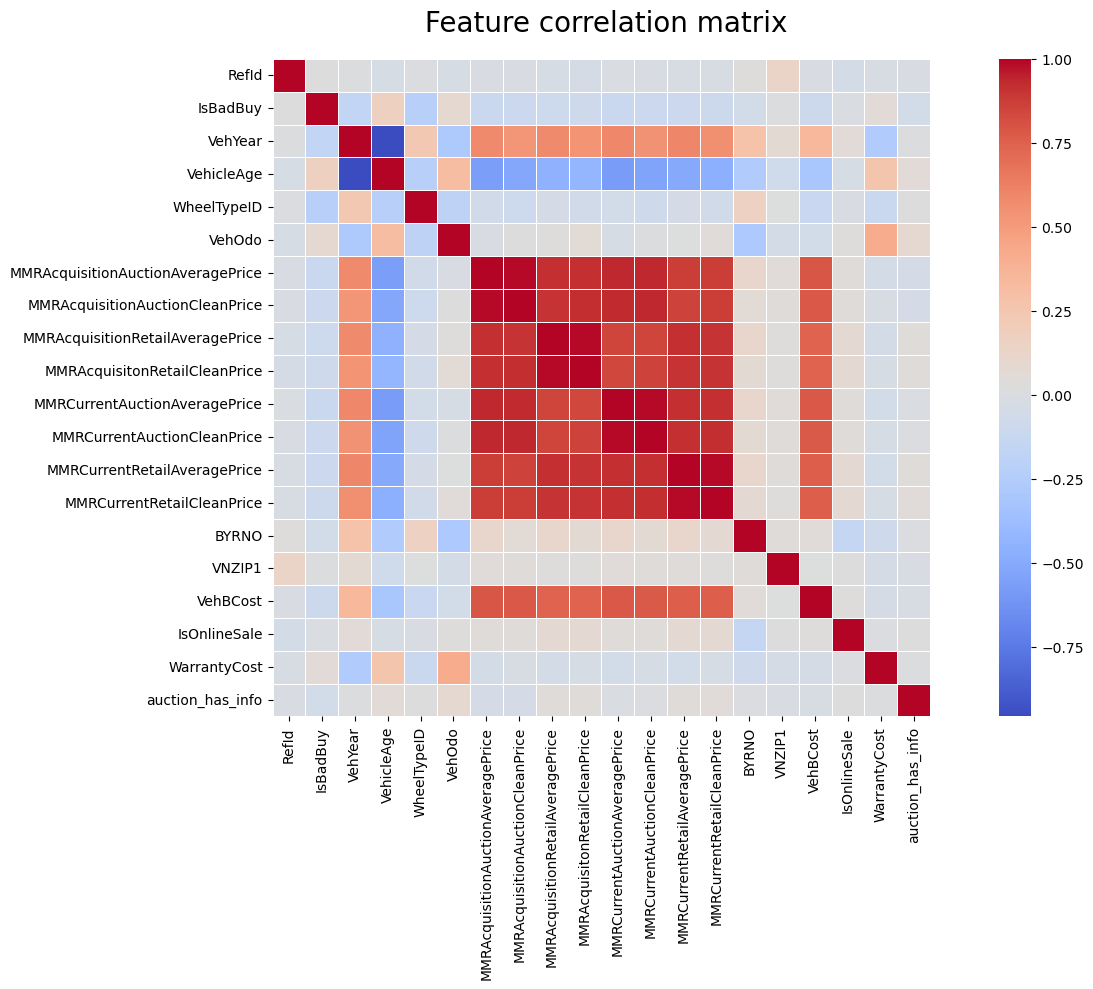

In [22]:
numeric_df = X.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(15, 10))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    # mask=mask,
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
)

plt.title(" Feature correlation matrix", fontsize=20, pad=20)
plt.tight_layout()
plt.show()

In [23]:
upper_indices = np.triu_indices_from(corr_matrix, k=1)

pairs = []
for i, j in zip(*upper_indices):
    corr_val = corr_matrix.iloc[i, j]
    if abs(corr_val) > 0.9:
        pairs.append((corr_matrix.index[i], corr_matrix.columns[j], corr_val))

print(f"\nFound {len(pairs)} pairs with correlation > 0.9:")
for f1, f2, val in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{f1:30} — {f2:30} : {val:+.3f}")


Found 21 pairs with correlation > 0.9:
MMRAcquisitionAuctionAveragePrice — MMRAcquisitionAuctionCleanPrice : +0.990
MMRCurrentAuctionAveragePrice  — MMRCurrentAuctionCleanPrice    : +0.990
MMRAcquisitionRetailAveragePrice — MMRAcquisitonRetailCleanPrice  : +0.990
MMRCurrentRetailAveragePrice   — MMRCurrentRetailCleanPrice     : +0.990
VehYear                        — VehicleAge                     : -0.958
MMRAcquisitionAuctionAveragePrice — MMRCurrentAuctionAveragePrice  : +0.938
MMRAcquisitionAuctionAveragePrice — MMRCurrentAuctionCleanPrice    : +0.932
MMRAcquisitionAuctionCleanPrice — MMRCurrentAuctionCleanPrice    : +0.932
MMRAcquisitionAuctionCleanPrice — MMRCurrentAuctionAveragePrice  : +0.924
MMRCurrentAuctionCleanPrice    — MMRCurrentRetailCleanPrice     : +0.922
MMRAcquisitionAuctionCleanPrice — MMRAcquisitonRetailCleanPrice  : +0.918
MMRCurrentAuctionAveragePrice  — MMRCurrentRetailAveragePrice   : +0.915
MMRAcquisitionRetailAveragePrice — MMRCurrentRetailAveragePrice   : +

In [24]:
pairs = []
for i, j in zip(*upper_indices):
    corr_val = corr_matrix.iloc[i, j]
    if abs(corr_val) > 0.7 and abs(corr_val) < 0.9:
        pairs.append((corr_matrix.index[i], corr_matrix.columns[j], corr_val))

print(f"\nFound {len(pairs)} pairs with correlation (> 0.7 and < 0.9):")
for f1, f2, val in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{f1:30} — {f2:30} : {val:+.3f}")


Found 16 pairs with correlation (> 0.7 and < 0.9):
MMRAcquisitionAuctionAveragePrice — MMRCurrentRetailAveragePrice   : +0.872
MMRAcquisitionAuctionCleanPrice — MMRCurrentRetailCleanPrice     : +0.871
MMRAcquisitionAuctionAveragePrice — MMRCurrentRetailCleanPrice     : +0.871
MMRAcquisitionAuctionCleanPrice — MMRCurrentRetailAveragePrice   : +0.861
MMRAcquisitonRetailCleanPrice  — MMRCurrentAuctionCleanPrice    : +0.856
MMRAcquisitionRetailAveragePrice — MMRCurrentAuctionAveragePrice  : +0.852
MMRAcquisitionRetailAveragePrice — MMRCurrentAuctionCleanPrice    : +0.849
MMRAcquisitonRetailCleanPrice  — MMRCurrentAuctionAveragePrice  : +0.847
MMRAcquisitionAuctionAveragePrice — VehBCost                       : +0.790
MMRAcquisitionAuctionCleanPrice — VehBCost                       : +0.781
MMRCurrentAuctionAveragePrice  — VehBCost                       : +0.779
MMRCurrentAuctionCleanPrice    — VehBCost                       : +0.775
MMRCurrentRetailAveragePrice   — VehBCost               

- **VehYear** and **VehicleAge** are inherently redundant (duplicate in nature). 
- I will retain only **VehicleAge**. 
- The data is highly multicollinear; further feature engineering will be required.

In [25]:
X = X.drop("VehYear", axis=1)

In [26]:
X.columns

Index(['RefId', 'IsBadBuy', 'PurchDate', 'Auction', 'VehicleAge', 'Make',
       'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID',
       'VehOdo', 'Nationality', 'Size', 'TopThreeAmericanName',
       'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
       'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
       'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
       'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'BYRNO',
       'VNZIP1', 'VNST', 'VehBCost', 'IsOnlineSale', 'WarrantyCost',
       'auction_has_info'],
      dtype='object')

## 2. Design the train/validation/test split

In [27]:
y = X["IsBadBuy"].copy()
X_fe = X.copy()
X = X.drop("IsBadBuy", axis=1)

In [28]:
X_train, X_valid, X_test, y_train, y_valid, y_test = time_ordered_split_3(
    X, y, date_field="PurchDate", train_size=1 / 3, valid_size=1 / 3, test_size=1 / 3
)

print(f"Train dates: {X_train['PurchDate'].min()} to {X_train['PurchDate'].max()}")
print(f"Valid dates: {X_valid['PurchDate'].min()} to {X_valid['PurchDate'].max()}")
print(f"Test dates: {X_test['PurchDate'].min()} to {X_test['PurchDate'].max()}")

Train dates: 2009-01-05 00:00:00 to 2009-09-16 00:00:00
Valid dates: 2009-09-16 00:00:00 to 2010-05-17 00:00:00
Test dates: 2010-05-17 00:00:00 to 2010-12-30 00:00:00


In [29]:
X_train = X_train.drop(columns="PurchDate")
X_valid = X_valid.drop(columns="PurchDate")
X_test = X_test.drop(columns="PurchDate")

## 3. Feature Encoding

In [30]:
X_train.select_dtypes(include=["object"]).head(5)

,Auction,Make,Model,Trim,SubModel,Color,Transmission,Nationality,Size,TopThreeAmericanName,VNST
32371,MANHEIM,CHRYSLER,PT CRUISER 2.4L I4 S,Lim,4D SEDAN LIMITED,GREY,AUTO,AMERICAN,MEDIUM,CHRYSLER,CO
32364,MANHEIM,GMC,YUKON 2WD V8 4.8L V8,SLE,4D UTILITY 4.8L SLE,WHITE,AUTO,AMERICAN,LARGE SUV,GM,CO
32363,MANHEIM,CHEVROLET,COLORADO PICKUP 2WD,LS,EXT CAB 3.5L LS,SILVER,AUTO,AMERICAN,SMALL TRUCK,GM,CO
32362,MANHEIM,FORD,ESCAPE 4WD V6 3.0L V,XLT,4D CUV 3.0L XLT,BLUE,AUTO,AMERICAN,SMALL SUV,FORD,CO
32361,MANHEIM,CHEVROLET,1500 SILVERADO PICKU,W/T,EXT CAB 5.3L LS,SILVER,AUTO,AMERICAN,LARGE TRUCK,GM,CO


In [31]:
X_train.select_dtypes(include=["object"]).nunique()

Auction                   3
Make                     31
Model                   805
Trim                    124
SubModel                663
Color                    16
Transmission              2
Nationality               4
Size                     12
TopThreeAmericanName      4
VNST                     29
dtype: int64

In [32]:
X.select_dtypes(include=["object"]).nunique()

PurchDate                517
Auction                    3
Make                      33
Model                   1060
Trim                     135
SubModel                 860
Color                     16
Transmission               3
Nationality                4
Size                      12
TopThreeAmericanName       4
VNST                      37
dtype: int64

LabelEncoder cannot be used, as the validation and test sets contain values that are not present in the training set.

In [33]:
ohe_cols = [
    "Auction",
    "Color",
    "Transmission",
    "Nationality",
    "Size",
    "TopThreeAmericanName",
]
ce_cols = ["Make", "Model", "Trim", "SubModel", "VNST"]
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    [
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ohe_cols,
        ),
        (
            "count",
            Pipeline(
                [
                    ("encoder", CountEncoder(handle_unknown=0)),
                    ("scaler", StandardScaler()),
                ]
            ),
            ce_cols,
        ),
        ("numeric", StandardScaler(), numeric_cols),
    ]
)
"""
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

ohe_feature_names = preprocessor.named_transformers_["onehot"].get_feature_names_out(
    ohe_cols
)
ce_feature_names = ce_cols
numeric_names = numeric_cols

all_feature_names = list(ohe_feature_names) + ce_feature_names + numeric_names

X_train_processed = pd.DataFrame(
    X_train_processed, columns=all_feature_names, index=X_train.index
)
X_valid_processed = pd.DataFrame(
    X_valid_processed, columns=all_feature_names, index=X_valid.index
)
X_test_processed = pd.DataFrame(
    X_test_processed, columns=all_feature_names, index=X_test.index
)
"""

'\nX_train_processed = preprocessor.fit_transform(X_train)\nX_valid_processed = preprocessor.transform(X_valid)\nX_test_processed = preprocessor.transform(X_test)\n\nohe_feature_names = preprocessor.named_transformers_["onehot"].get_feature_names_out(\n    ohe_cols\n)\nce_feature_names = ce_cols\nnumeric_names = numeric_cols\n\nall_feature_names = list(ohe_feature_names) + ce_feature_names + numeric_names\n\nX_train_processed = pd.DataFrame(\n    X_train_processed, columns=all_feature_names, index=X_train.index\n)\nX_valid_processed = pd.DataFrame(\n    X_valid_processed, columns=all_feature_names, index=X_valid.index\n)\nX_test_processed = pd.DataFrame(\n    X_test_processed, columns=all_feature_names, index=X_test.index\n)\n'

## 4. Gini

In [34]:
def gini_normalized(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    def gini_simple(y_true, y_pred):
        n = len(y_true)

        idx = np.argsort(y_pred)
        y_true_sorted = y_true[idx]

        index = np.arange(1, n + 1)

        return (2 * np.sum(index * y_true_sorted) / (n * np.sum(y_true_sorted))) - (
            n + 1
        ) / n

    return gini_simple(y_true, y_pred) / gini_simple(y_true, y_true)

## 5. Model

### 5.1 LogisticRegression

In [35]:
pipeline_1 = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=21, max_iter=1000)),
    ]
)

pipeline_1.fit(X_train, y_train)
y_valid_proba_lr = pipeline_1.predict_proba(X_valid)[:, 1]

gini_normalized(y_valid, y_valid_proba_lr)

0.412073802606117

In [36]:
auc = roc_auc_score(y_valid, y_valid_proba_lr)
gini = 2 * auc - 1
gini

0.41207380260611703

### 5.2 Gaussian Naive Bayes

In [37]:
pipeline_2 = Pipeline([("preprocessor", preprocessor), ("model", GaussianNB())])

pipeline_2.fit(X_train, y_train)
y_valid_proba_nb = pipeline_2.predict_proba(X_valid)[:, 1]

gini_normalized(y_valid, y_valid_proba_nb)

0.2946088083382735

### 5.3 KNeighborsClassifier

In [38]:
pipeline_3 = Pipeline(
    [("preprocessor", preprocessor), ("model", KNeighborsClassifier())]
)

pipeline_3.fit(X_train, y_train)
y_valid_proba_kn = pipeline_3.predict_proba(X_valid)[:, 1]

gini_normalized(y_valid, y_valid_proba_kn)

0.2676815805754984

Logistic Regression yields the highest Gini coefficient (0.41), as it is robust to noise, performs well on linearly separable data, and does not require feature independence (unlike Naive Bayes) or large sample sizes (unlike KNN).

## 6. Model Custom

### 6.1 LogisticRegression

In [39]:
class MyLogisticRegression(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.losses = []

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.classifier_tags = None
        return tags

    def _sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        if hasattr(X, "values"):
            X = X.values
        if hasattr(y, "values"):
            y = y.values

        n_samples, n_features = X.shape

        self.weights_ = np.zeros(n_features)
        self.bias_ = 0
        self.losses_ = []

        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.weights_) + self.bias_
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights_ -= self.learning_rate * dw
            self.bias_ -= self.learning_rate * db

            loss = -np.mean(
                y * np.log(y_predicted + 1e-15)
                + (1 - y) * np.log(1 - y_predicted + 1e-15)
            )
            self.losses_.append(loss)

            if i > 0 and abs(self.losses_[-1] - self.losses_[-2]) < self.tolerance:
                break

        return self

    def predict_proba(self, X):
        if hasattr(X, "values"):
            X = X.values

        linear_model = np.dot(X, self.weights_) + self.bias_
        proba_class_1 = self._sigmoid(linear_model)
        return np.column_stack([1 - proba_class_1, proba_class_1])

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

In [40]:
pipeline_01 = Pipeline(
    [("preprocessor", preprocessor), ("model", MyLogisticRegression())]
)

pipeline_01.fit(X_train, y_train)
y_valid_proba_01 = pipeline_01.predict_proba(X_valid)[:, 1]

gini_normalized(y_valid, y_valid_proba_01)

0.3936729906973944

### 6.2 Gaussian Naive Bayes

In [41]:
class MyNaiveBayes(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        return tags

    def fit(self, X, y):
        if hasattr(X, "values"):
            X = X.values
        if hasattr(y, "values"):
            y = y.values

        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))
        self.vars_ = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.priors_[idx] = len(X_c) / n_samples
            self.means_[idx] = X_c.mean(axis=0)
            self.vars_[idx] = X_c.var(axis=0) + self.alpha

        return self

    def _gaussian_pdf(self, X, mean, var):
        coef = 1 / np.sqrt(2 * np.pi * var)
        exponent = np.exp(-((X - mean) ** 2) / (2 * var))
        return coef * exponent

    def predict_proba(self, X):
        if hasattr(X, "values"):
            X = X.values

        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        log_probs = np.zeros((n_samples, n_classes))

        for idx in range(n_classes):
            prior = np.log(self.priors_[idx])
            likelihood = np.sum(
                np.log(
                    self._gaussian_pdf(X, self.means_[idx], self.vars_[idx]) + 1e-15
                ),
                axis=1,
            )
            log_probs[:, idx] = prior + likelihood

        log_probs = log_probs - log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs = probs / probs.sum(axis=1, keepdims=True)

        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]

In [42]:
pipeline_02 = Pipeline([("preprocessor", preprocessor), ("model", MyNaiveBayes())])

pipeline_02.fit(X_train, y_train)
y_valid_proba_02 = pipeline_02.predict_proba(X_valid)[:, 1]

gini_normalized(y_valid, y_valid_proba_02)

0.33650163491058677

### 6.3 KNeighborsClassifier

In [43]:
class MyKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, n_neighbors=5, metric="euclidean"):
        self.n_neighbors = n_neighbors
        self.metric = metric

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        return tags

    def fit(self, X, y):
        if hasattr(X, "values"):
            X = X.values
        if hasattr(y, "values"):
            y = y.values

        self.X_train_ = X
        self.y_train_ = y
        return self

    def predict_proba(self, X):
        if hasattr(X, "values"):
            X = X.values

        if self.metric == "euclidean":
            # ||a - b||^2 = ||a||^2 + ||b||^2 - 2 * a @ b.T
            X_norm = np.sum(X**2, axis=1, keepdims=True)
            X_train_norm = np.sum(self.X_train_**2, axis=1, keepdims=True)
            distances = np.sqrt(
                X_norm + X_train_norm.T - 2 * np.dot(X, self.X_train_.T)
            )
        elif self.metric == "manhattan":
            distances = np.sum(
                np.abs(X[:, np.newaxis, :] - self.X_train_[np.newaxis, :, :]), axis=2
            )
        else:
            raise ValueError(f"Unknown metric: {self.metric}")

        k_indices = np.argsort(distances, axis=1)[:, : self.n_neighbors]
        k_labels = self.y_train_[k_indices]

        prob_class_1 = np.mean(k_labels == 1, axis=1)
        prob_class_0 = 1 - prob_class_1

        return np.column_stack([prob_class_0, prob_class_1])

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

In [44]:
pipeline_03 = Pipeline([("preprocessor", preprocessor), ("model", MyKNN())])

pipeline_03.fit(X_train, y_train)
y_valid_proba_03 = pipeline_03.predict_proba(X_valid)[:, 1]

gini_normalized(y_valid, y_valid_proba_03)

0.2676815805754984

## 7. Feature Engineering

### 7.1 Acquisition_Ratio

VehBCost / MMRAcquisitionAuctionAveragePrice

### Business Interpretation: 

| Value | Meaning | Business Implication |
|-------|---------|----------------------|
| = 1.0 | Bought at market | Neutral |
| > 1.0 | **Overpaid** (e.g., 1.05 = +5%) | Higher loss risk |
| < 1.0 | **Discount** (e.g., 0.95 = -5%) | Margin of safety |

In [45]:
X_fe["Acquisition_Ratio"] = X_fe["VehBCost"] / X_fe["MMRAcquisitionAuctionAveragePrice"]
X_fe["Acquisition_Ratio"] = X_fe["Acquisition_Ratio"].replace([np.inf, -np.inf], 1.0)

### 7.2 Market_Decay

MMRCurrentAuctionAveragePrice / MMRAcquisitionAuctionAveragePrice

### Business Interpretation:

| Value | Meaning | Business Impact |
|-------|---------|-----------------|
| = 1.0 | Stable market | Neutral |
| > 1.0 | Appreciating (shortage) | Positive — vehicle gains value |
| < 1.0 | Depreciating (decline) | Negative — margin erosion over time |

**Attribution Insight:**
- Bad buy **+** Decay < 1.0 → Market-driven loss (external factor).
- Bad buy **+** Decay ≥ 1.0 → Buyer-driven loss (overpayment).

In [46]:
X_fe["Market_Decay"] = (
    X_fe["MMRCurrentAuctionAveragePrice"] / X_fe["MMRAcquisitionAuctionAveragePrice"]
)
X_fe["Market_Decay"] = X_fe["Market_Decay"].replace([np.inf, -np.inf], 1.0)
X_fe["Market_Decay"] = X_fe["Market_Decay"].fillna(1.0)

### 7.3 Liquidity_Spread

MMRCurrentRetailAveragePrice / MMRCurrentAuctionAveragePrice

### Business Interpretation

**"How easy and profitable is it to resell this vehicle at retail?"**

- **= 1.0** — Retail offers no premium. The vehicle can only be sold at wholesale auction price. This is **illiquid inventory**.
- **> 1.15** — Strong retail demand. There is a healthy margin between wholesale and retail pricing. This is a **fast-moving unit**.

In [47]:
df["Liquidity_Spread"] = (
    df["MMRCurrentRetailAveragePrice"] / df["MMRCurrentAuctionAveragePrice"]
)

### 7.4 Clean_Premium_Pct

(MMRCurrentAuctionCleanPrice - MMRCurrentAuctionAveragePrice) / MMRCurrentAuctionAveragePrice

### Business Interpretation: 

| Value | Market Sensitivity | Implication |
|-------|-------------------|-------------|
| ≈ 0.02 (2%)| **Low sensitivity** | Condition has minimal impact on price. Reconditioning may not pay off. |
| ≈ 0.15 (15%) | **High sensitivity** | Condition drives significant price variance. Reconditioning investment likely justified. |

**Strategic Use:** Determines whether investing in reconditioning (detailing, minor repairs) will yield a positive return at sale.

In [48]:
df["Clean_Premium_Pct"] = (
    df["MMRCurrentAuctionCleanPrice"] - df["MMRCurrentAuctionAveragePrice"]
) / df["MMRCurrentAuctionAveragePrice"]

In [49]:
X_fe.columns

Index(['RefId', 'IsBadBuy', 'PurchDate', 'Auction', 'VehicleAge', 'Make',
       'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID',
       'VehOdo', 'Nationality', 'Size', 'TopThreeAmericanName',
       'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
       'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
       'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
       'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'BYRNO',
       'VNZIP1', 'VNST', 'VehBCost', 'IsOnlineSale', 'WarrantyCost',
       'auction_has_info', 'Acquisition_Ratio', 'Market_Decay'],
      dtype='object')

In [50]:
columns_drop_2 = [
    "RefId",
    "VehBCost",
    "MMRAcquisitionAuctionCleanPrice",
    # "MMRAcquisitionRetailAveragePrice",
    "MMRAcquisitonRetailCleanPrice",
    # "MMRCurrentAuctionAveragePrice",
    "MMRCurrentAuctionCleanPrice",
    "MMRCurrentRetailCleanPrice",
]
X_fe = X_fe.drop(columns=columns_drop_2)

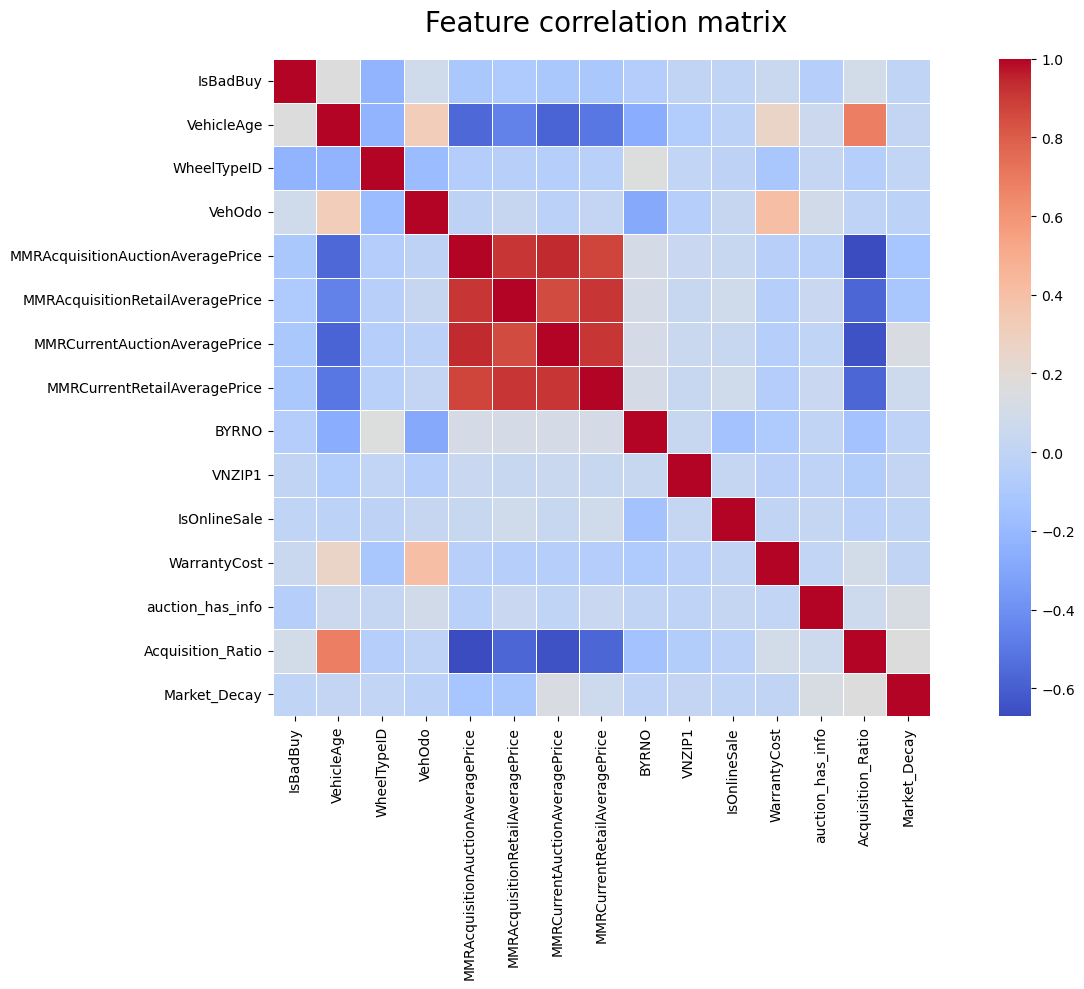

In [51]:
numeric_df_2 = X_fe.select_dtypes(include=["number"])
corr_matrix_2 = numeric_df_2.corr()
plt.figure(figsize=(15, 10))

sns.heatmap(corr_matrix_2, cmap="coolwarm", square=True, linewidths=0.5)

plt.title(" Feature correlation matrix", fontsize=20, pad=20)
plt.tight_layout()
plt.show()

In [52]:
X_fe = X_fe.drop("IsBadBuy", axis=1)
X_train_fe, X_valid_fe, X_test_fe, y_train, y_valid, y_test = time_ordered_split_3(
    X_fe, y, date_field="PurchDate", train_size=1 / 3, valid_size=1 / 3, test_size=1 / 3
)

In [53]:
numeric_cols_2 = X_train_fe.select_dtypes(include=["number"]).columns.tolist()

preprocessor_v2 = ColumnTransformer(
    [
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ohe_cols,
        ),
        (
            "count",
            Pipeline(
                [
                    ("encoder", CountEncoder(handle_unknown=0)),
                    ("scaler", StandardScaler()),
                ]
            ),
            ce_cols,
        ),
        ("numeric", StandardScaler(), numeric_cols_2),
    ]
)

In [54]:
pipeline_1_v2 = Pipeline(
    [
        ("preprocessor", preprocessor_v2),
        ("model", LogisticRegression(random_state=21, max_iter=1000)),
    ]
)

pipeline_1_v2.fit(X_train_fe, y_train)
y_valid_proba_lr_2 = pipeline_1_v2.predict_proba(X_valid_fe)[:, 1]

gini_normalized(y_valid, y_valid_proba_lr_2)

0.41585057163584294

In [55]:
pipeline_2_v2 = Pipeline([("preprocessor", preprocessor_v2), ("model", GaussianNB())])

pipeline_2_v2.fit(X_train_fe, y_train)
y_valid_proba_nb_v2 = pipeline_2_v2.predict_proba(X_valid_fe)[:, 1]

gini_normalized(y_valid, y_valid_proba_nb_v2)

0.29975060085848376

In [56]:
pipeline_3_v2 = Pipeline(
    [("preprocessor", preprocessor_v2), ("model", KNeighborsClassifier())]
)

pipeline_3_v2.fit(X_train_fe, y_train)
y_valid_proba_kn_v2 = pipeline_3_v2.predict_proba(X_valid_fe)[:, 1]

gini_normalized(y_valid, y_valid_proba_kn_v2)

0.2764411414335309

All models showed a slight improvement. However, adding the grouped feature led to a drop in performance. 

```
model_risk_map = X_train.groupby('Model')['IsBadBuy'].mean()

X_train['Model_Risk'] = X_train['Model'].map(model_risk_map)
X_valid['Model_Risk'] = X_valid['Model'].map(model_risk_map)
X_test['Model_Risk'] = X_test['Model'].map(model_risk_map)

global_mean = y_train.mean()
X_valid['Model_Risk'] = X_valid['Model_Risk'].fillna(global_mean)
X_test['Model_Risk'] = X_test['Model_Risk'].fillna(global_mean)
```

## 8. The coefficients

In [57]:
df_2 = pd.read_csv("../datasets/train.csv")
y_2 = df_2["IsBadBuy"].copy()
df_2 = df_2.drop(columns="IsBadBuy")

In [58]:
numeric_cols = df_2.select_dtypes(include=["number"]).columns
df_2[numeric_cols] = df_2[numeric_cols].fillna(0.0)

non_numeric_cols = df_2.select_dtypes(exclude=["number"]).columns
df_2[non_numeric_cols] = df_2[non_numeric_cols].fillna("unknown")

In [59]:
X_train_2, X_valid_2, X_test_2, y_train_2, y_valid_2, y_test_2 = time_ordered_split_3(
    df_2,
    y_2,
    date_field="PurchDate",
    train_size=1 / 3,
    valid_size=1 / 3,
    test_size=1 / 3,
)
X_train_2 = X_train_2.drop(columns="PurchDate")
X_valid_2 = X_valid_2.drop(columns="PurchDate")
X_test_2 = X_test_2.drop(columns="PurchDate")

In [60]:
X_train_2.select_dtypes(include=["object"]).nunique()

Auction                   3
Make                     31
Model                   801
Trim                    123
SubModel                664
Color                    17
Transmission              3
WheelType                 4
Nationality               4
Size                     12
TopThreeAmericanName      4
PRIMEUNIT                 2
AUCGUART                  2
VNST                     29
dtype: int64

In [61]:
ohe_cols_2 = [
    "Auction",
    "Color",
    "Transmission",
    "WheelType",
    "Nationality",
    "Size",
    "TopThreeAmericanName",
    "PRIMEUNIT",
    "AUCGUART",
]
ce_cols_2 = ["Make", "Model", "Trim", "SubModel", "VNST"]
numeric_cols_2 = X_train_2.select_dtypes(include=["number"]).columns.tolist()

preprocessor_2 = ColumnTransformer(
    [
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ohe_cols_2,
        ),
        (
            "count",
            Pipeline(
                [
                    ("encoder", CountEncoder(handle_unknown=0)),
                    ("scaler", StandardScaler()),
                ]
            ),
            ce_cols_2,
        ),
        ("numeric", StandardScaler(), numeric_cols_2),
    ]
)

X_train_processed = preprocessor_2.fit_transform(X_train_2)
X_valid_processed = preprocessor_2.transform(X_valid_2)
X_test_processed = preprocessor_2.transform(X_test_2)

ohe_feature_names = preprocessor_2.named_transformers_["onehot"].get_feature_names_out(
    ohe_cols_2
)
ce_feature_names = ce_cols_2
numeric_names = numeric_cols_2

all_feature_names = list(ohe_feature_names) + ce_feature_names + numeric_names

X_train_processed = pd.DataFrame(
    X_train_processed, columns=all_feature_names, index=X_train_2.index
)
X_valid_processed = pd.DataFrame(
    X_valid_processed, columns=all_feature_names, index=X_valid_2.index
)
X_test_processed = pd.DataFrame(
    X_test_processed, columns=all_feature_names, index=X_test_2.index
)

In [62]:
model = LogisticRegression(penalty="l1", solver="saga", C=0.1, random_state=21)
model.fit(X_train_processed, y_train_2)
weights = model.coef_[0]
feature_importance = pd.Series(weights, index=all_feature_names)

/Users/dataalph/goinfre/conda_envs/ml_project/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dataalph/goinfre/conda_envs/ml_project/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/dataalph/goinfre/conda_envs/ml_project/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [63]:
important = feature_importance[feature_importance != 0].sort_values(ascending=False)
print(len(important))
important

39


WheelType_unknown                  0.953686
TopThreeAmericanName_FORD          0.174541
VehOdo                             0.144441
Size_MEDIUM SUV                    0.131986
VehicleAge                         0.126735
MMRAcquisitionAuctionCleanPrice    0.114259
SubModel                           0.089709
RefId                              0.082798
WarrantyCost                       0.073908
VNZIP1                             0.050274
VNST                               0.038571
WheelType_Special                  0.036821
Color_RED                          0.034673
Auction_MANHEIM                    0.033763
Size_COMPACT                       0.032437
Size_MEDIUM                        0.029326
Trim                               0.018999
Color_BLACK                        0.017919
Color_GOLD                         0.008296
Size_SMALL SUV                    -0.007008
Color_GREEN                       -0.010663
Auction_OTHER                     -0.037113
Size_LARGE TRUCK                

In [64]:
y_valid_proba = model.predict_proba(X_valid_processed)[:, 1]
gini_normalized(y_valid_2, y_valid_proba)

0.4719801545022785

L1 regularization achieved better results (0.47198) at zeroing out features than my approach (0.41585)

## 9 The best model

In [65]:
param_dist = {"C": uniform(0.01, 10), "solver": ["saga", "liblinear"]}

model_v2 = LogisticRegression(penalty="l1", random_state=21)

random_search = RandomizedSearchCV(
    model_v2,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    random_state=21,
    n_jobs=-1,
)

random_search.fit(X_train_processed, y_train_2)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best score: {random_search.best_score_}")

best_model = random_search.best_estimator_

/Users/dataalph/goinfre/conda_envs/ml_project/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dataalph/goinfre/conda_envs/ml_project/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/dataalph/goinfre/conda_envs/ml_project/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

Best parameters: {'C': 0.22616249915949793, 'solver': 'saga'}
Best score: 0.7425927781048778


/Users/dataalph/goinfre/conda_envs/ml_project/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters: {'C': 0.22616249915949793, 'solver': 'saga'}

Best score: 0.7425927781048778 (roc_auc)

## 10.  The Gini scores 

In [66]:
y_train_proba = best_model.predict_proba(X_train_processed)[:, 1]
gini_normalized(y_train_2, y_train_proba)

0.5112805332402354

In [67]:
y_valid_proba = best_model.predict_proba(X_valid_processed)[:, 1]
gini_normalized(y_valid_2, y_valid_proba)

0.47228916144845345

In [68]:
y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]
gini_normalized(y_test_2, y_test_proba)

0.44807171362564485

There is no overfitting. The model demonstrates stable performance on the held-out sets, with a natural slight decline on the final test set. The minor drop from validation to test is not indicative of overfitting; it merely reflects natural data variation and the soundness of the evaluation procedure.

## 11. Custom metrics

![gkf](../misc/images/1.jpg)

In [69]:
def precision_score(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))

    if tp + fp == 0:
        return 0.0
    return tp / (tp + fp)

In [70]:
def recall_score(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    if tp + fn == 0:
        return 0.0
    return tp / (tp + fn)

In [71]:
def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)

    if p + r == 0:
        return 0.0
    return 2 * (p * r) / (p + r)

In [72]:
def precision_recall_curve(y_true, y_scores):
    if hasattr(y_true, "values"):
        y_true = y_true.values
    if hasattr(y_scores, "values"):
        y_scores = y_scores.values

    sorted_indices = np.argsort(-y_scores)
    y_true_sorted = y_true[sorted_indices]

    tp = 0
    fp = 0

    precision = []
    recall = []

    total_positives = np.sum(y_true == 1)

    if total_positives == 0:
        return np.array([1.0]), np.array([0.0])

    for i in range(len(y_true_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1

        p = tp / (tp + fp) if (tp + fp) > 0 else 1.0
        r = tp / total_positives

        precision.append(p)
        recall.append(r)

    return np.array(precision), np.array(recall)

In [73]:
def auc_pr(y_true, y_scores):
    precision, recall = precision_recall_curve(y_true, y_scores)

    sorted_indices = np.argsort(recall)
    recall_sorted = recall[sorted_indices]
    precision_sorted = precision[sorted_indices]

    recall_sorted = np.concatenate([[0], recall_sorted, [1]])
    precision_sorted = np.concatenate([[1], precision_sorted, [0]])

    return np.trapz(precision_sorted, recall_sorted)

In [74]:
models = {
    "LogReg": pipeline_1,
    "NaiveBayes": pipeline_2,
    "KNN": pipeline_3,
}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    print(f"\n{name}")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("PR-AUC:", auc_pr(y_test, y_proba))


LogReg
Precision: 0.06518010291595197
Recall: 0.07607607607607608
F1: 0.07020785219399539
PR-AUC: 0.15614012396530544

NaiveBayes
Precision: 0.05389848246991104
Recall: 0.06873540206873541
F1: 0.06041941633670626
PR-AUC: 0.13663176237785046

KNN
Precision: 0.25
Recall: 0.11644978311644978
F1: 0.1588891418165263
PR-AUC: 0.18004417583728627


In [75]:
y_pred = (y_test_proba >= 0.5).astype(int)
print(f"The best")
print("Precision:", precision_score(y_test_2, y_pred))
print("Recall:", recall_score(y_test_2, y_pred))
print("F1:", f1_score(y_test_2, y_pred))
print("PR-AUC:", auc_pr(y_test_2, y_test_proba))

The best
Precision: 0.8218527315914489
Recall: 0.2292909211398277
F1: 0.3585492227979275
PR-AUC: 0.4040678449098079


In [76]:
y_test.value_counts()

IsBadBuy
0    21223
1     2997
Name: count, dtype: int64

## Baseline Models: Poor Performance (Expected)

Logistic Regression, GaussianNB, and KNN (default hyperparameters) scored F1 = 0.06–0.16.
Precision ≤ 25%, Recall ≤ 12%. Effectively useless under class imbalance.

## Tuned Model: Breakthrough

| Metric | Baseline (LogReg) | Tuned Linear Classifier | Improvement |
|--------|--------------------|-------------------------|-------------|
| Precision | 0.07 | **0.82** | ~12× |
| Recall | 0.08 | **0.23** | ~3× |
| F1-score | 0.06–0.16 | **0.359** | Best overall |
| PR-AUC | 0.16 | **0.404** | Strong signal (imbalanced setting) |

**Takeaway:** Hyperparameter tuning is decisive. The tuned model extracts real signal; baseline models do not.

## 12. Which hard label metric do you prefer for the task of detecting "lemon" cars?

For the task of detecting "bad buys," I would choose Recall as the primary metric, because missing a bad vehicle leads to direct financial losses.

At the same time, I would monitor Precision to avoid discarding too many good vehicles, and use F1-score to strike a balance.

ROC-AUC can serve as a supplementary metric to assess ranking quality.